**for reference**

New improved mapping with both 16x `SphereStripe` (=16x 60 RGB LEDs) and 6x `ArmConfig` (each 1x or 2x 2x60 RGB LEDs), mapping to a single array of 60x(16+8x2)=1920 pixels.

- the final 1920x3 RGB value pixel is sent to 4x Fadecandy (note each mapping 480 to 512 pixels by appending 4 ghost pixels after every 60 pixels for a single stripe)

- the final 1920x3 RGB value pixel is also set over websocket for display in the webapp

- the `(phi, r)`-mapping (1920x2) maps every single pixel to an idealized flat space; note that r=1 specifies the rim, but the projection in the sphere and on the arms can be variable

- every possible `(x, y, z)` (or `(phi, theta, xi, dist)`) camera position maps to a distinct `(x, y)`-mapping (1920x2) for perspective display of a 2D surface from a single camera point

In [1]:
# verify version
import sys
assert sys.version.split('.')[0] == '3'
!which python

/Users/andreassteiner/git/nuru/env/bin/python


In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import collections, base64, io, json

from matplotlib import pyplot as plt
from mpl_toolkits import mplot3d
from PIL import Image, ImageDraw
from IPython import display
import numpy as np

import os.path, sys

lib_path = '../py'
assert os.path.exists(lib_path), 'Make sure "." path is where notebooks are!'
if not lib_path in sys.path:
    sys.path.insert(0, lib_path)

from smanmi import logic as L, signals as S
from nuru import mapping, settings, animations as A, pixel_functions as pf

def show(im):
    with io.BytesIO() as f:
        im.save(f, format='png')
        data = f.getvalue()
        display.display(display.HTML(
            '<img src="data:image/png;base64,{0}" />'.format(
            base64.b64encode(f.getvalue()).decode('utf-8'))))


# 3D

$(x, y, z)$ coordinates from Blender model fitted on Kinect 3D point cloud - see `../blender/kinect_lowres.blend`

slides from [NURU SHIMONI](https://docs.google.com/presentation/d/1kWKOjcJiLdcVQkaqHcMZZdBt3DM2olypaQvjHZF1c8I/edit) :

![mapping 3D](mapping_3D.png)

In [4]:
# this file can be generated in Blender with export_kinect_mapping.py
kinect_mapping = json.load(open('../blender/data/kinect_mapping.json'))
kinect_mapping[0]

{'co': [-0.3137463629245758, -0.017990052700042725, -0.2540675401687622],
 'idx': '000',
 'strip_name': 'arm_1-1'}

In [6]:
xyz_mapping = mapping.generate_xyz_mapping(kinect_mapping, settings.arm_mapping)

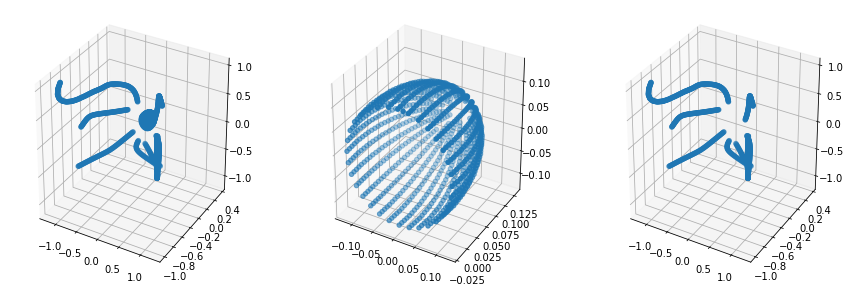

In [7]:
fig = plt.figure(figsize=(15, 5))
fig.add_subplot(131, projection='3d').scatter(*xyz_mapping.T)
fig.add_subplot(132, projection='3d').scatter(*xyz_mapping[:960].T)
fig.add_subplot(133, projection='3d').scatter(*xyz_mapping[960:].T)
None

# 2D

$(\phi, \theta)$ mapping derived from topology mapped on two dimensions

slides from [NURU SHIMONI](https://docs.google.com/presentation/d/1kWKOjcJiLdcVQkaqHcMZZdBt3DM2olypaQvjHZF1c8I) :

![mapping 2D](mapping_2D.png)

In [ ]:
class Display:

    def __init__(self, phi_r_mapping, width=800, height=600):
        self.phi_r_mapping = phi_r_mapping
        self.width = width
        self.height = height
        self.scale = lambda r: r * 77

    def circle(self, draw, phi, r, col, d=5):
        x = self.width / 2 + np.sin(phi) * self.scale(r)
        y = self.height / 2 - np.cos(phi) * self.scale(r)
        draw.ellipse((x-d/2, y-d/2, x+d/2, y+d/2), fill=tuple(col))

    def draw(self, rgb):
        """Colors in `rgb` range from 0..1 for every pixel."""
        im = Image.new('RGB', (self.width, self.height), 'black')
        draw = ImageDraw.Draw(im)

        rgb = (255 * rgb).astype('uint8')
        for (phi, r), col in zip(self.phi_r_mapping, rgb):
            self.circle(draw, phi, r, col)
        return im



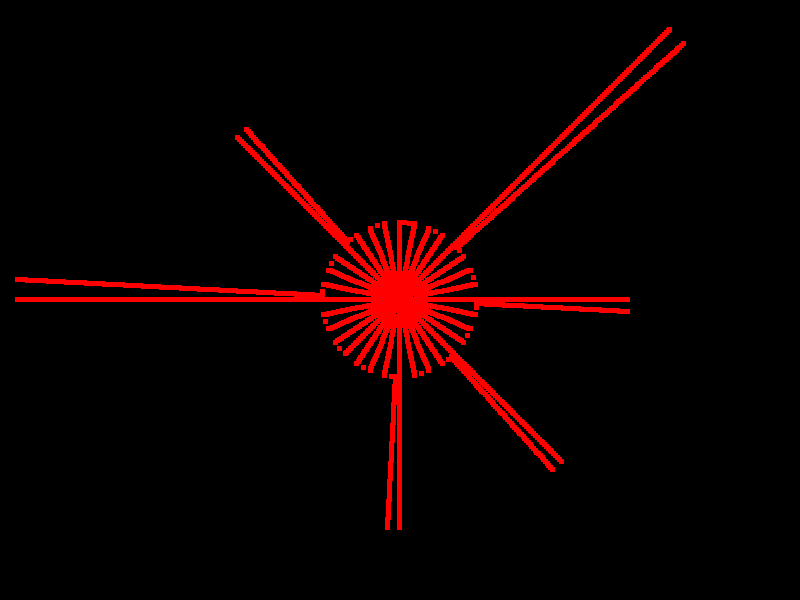

In [11]:
phi_r_mapping = mapping.generate_arm_configs(settings.arm_configs)
phi_r_mapping[:2*8*60, :] = mapping.generate_sphere_mapping(settings.sphere_strips)

disp = Display(phi_r_mapping)
signals = dict(fc=3)
animation = A.FullOn([1, 0, 0])
# animation = A.PositionIdentify()

show(disp.draw(animation(**signals)['value']))

In [16]:
# for inlining in js
digits = 5
print('const mapping = [{}]'.format(','.join([
    '[{},{}]'.format(str(phi)[:digits + 2], str(r)[:digits + 2])
    for phi, r in phi_r_mapping
])))

const mapping = [[0.0,0.0625],[0.0,0.09375],[0.0,0.125],[0.0,0.15625],[0.0,0.1875],[0.0,0.21875],[0.0,0.25],[0.0,0.28125],[0.0,0.3125],[0.0,0.34375],[0.0,0.375],[0.0,0.40625],[0.0,0.4375],[0.0,0.46875],[0.0,0.5],[0.0,0.53125],[0.0,0.5625],[0.0,0.59375],[0.0,0.625],[0.0,0.65625],[0.0,0.6875],[0.0,0.71875],[0.0,0.75],[0.0,0.78125],[0.0,0.8125],[0.0,0.84375],[0.0,0.875],[0.0,0.90625],[0.0,0.9375],[0.0,0.96875],[0.0,1.0],[0.06544,1.0],[0.13089,1.0],[0.19634,1.0],[0.19634,0.96875],[0.19634,0.9375],[0.19634,0.90625],[0.19634,0.875],[0.19634,0.84375],[0.19634,0.8125],[0.19634,0.78125],[0.19634,0.75],[0.19634,0.71875],[0.19634,0.6875],[0.19634,0.65625],[0.19634,0.625],[0.19634,0.59375],[0.19634,0.5625],[0.19634,0.53125],[0.19634,0.5],[0.19634,0.46875],[0.19634,0.4375],[0.19634,0.40625],[0.19634,0.375],[0.19634,0.34375],[0.19634,0.3125],[0.19634,0.28125],[0.19634,0.25],[0.19634,0.21875],[0.19634,0.1875],[0.39269,0.03125],[0.39269,0.0625],[0.39269,0.09375],[0.39269,0.125],[0.39269,0.15625],[0.39

### voronoi

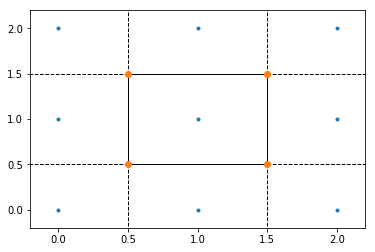

In [12]:
# https://docs.scipy.org/doc/scipy-0.18.1/reference/generated/scipy.spatial.Voronoi.html

points = np.array([[0, 0], [0, 1], [0, 2], [1, 0], [1, 1], [1, 2],
                   [2, 0], [2, 1], [2, 2]])
from scipy.spatial import Voronoi, voronoi_plot_2d
vor = Voronoi(points)

import matplotlib.pyplot as plt
voronoi_plot_2d(vor)
plt.show()

In [17]:
# e.g. indices of Voronoi region in the middle (original point #5)
[vor.vertices[idx] for idx in vor.regions[vor.point_region[4]]]

[array([1.5, 1.5]), array([0.5, 1.5]), array([0.5, 0.5]), array([1.5, 0.5])]

In [18]:
# runs in 0s
x_y_mapping = [
  (r * np.sin(phi), -r * np.cos(phi))
  for phi, r in phi_r_mapping
]
vorr = Voronoi(x_y_mapping)

(0, 2)

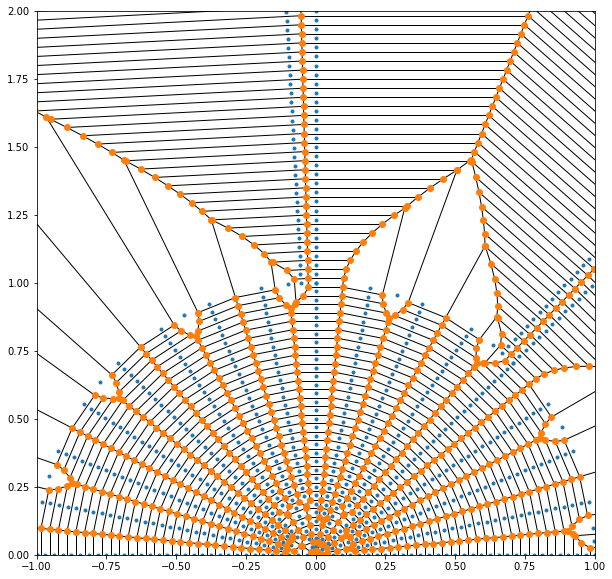

In [36]:
# -> arms need to be shaped !
plt.figure(figsize=(10, 10))
voronoi_plot_2d(vorr, ax=plt.gca())
x0, y0 = 0, 1
d = 1
plt.gca().set_xlim([x0-d, x0+d])
plt.gca().set_ylim([y0-d, y0+d])

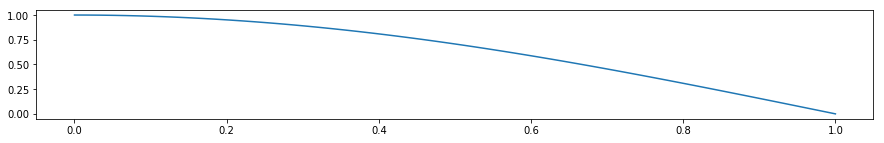

In [40]:
# TODO : shape arms with a function like below & add (inactive) neighboring points for shaping
plt.figure(figsize=(15, 2))
xs = np.linspace(0, 1, 60)
plt.plot(xs, np.cos(xs * np.pi / 2))

### resultig modifications

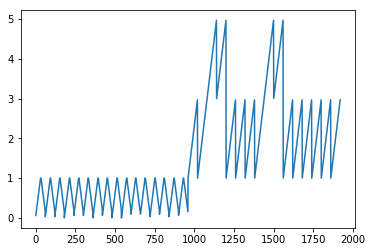

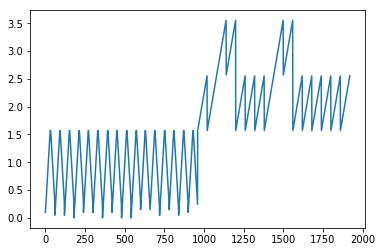

In [111]:
plt.plot(phi_r_mapping[:, 1])
plt.figure()
plt.plot(A.r_piecewise(phi_r_mapping[:, 1]));


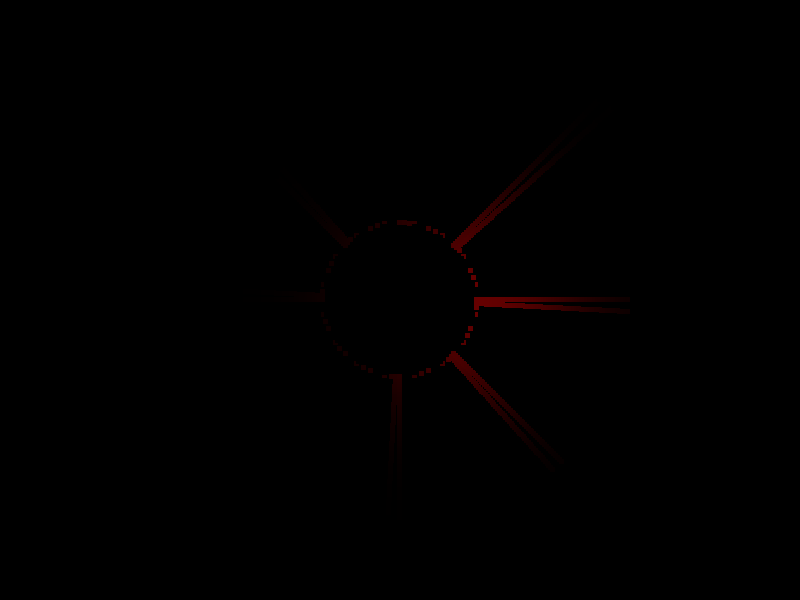

In [182]:
# WIP

sphere = phi_r_mapping[:, 1:2] < 1
rgb = pf.r_phi_gaussian_1d(phi_r_mapping, [np.pi/2, 1], 1, [1, 0, 0]) * ~sphere

disp = Display(phi_r_mapping)
show(disp.draw(rgb))